# Dimensionality Reduction – Heart Failure Prediction Dataset
*PCA, t-SNE, UMAP for the Heart Failure Prediction Dataset*  

---
## Table of Contents
1. [Setup](#setup)  
    1.2 [Imports and Reproducibility](#imports-and-reproducibility)  
    1.2 [Data Loading](#data-loading)  
    2.1 [Feature Pruning](#feature-prunning)  

2. [PCA](#pca)  
    2.1 [Variance Explained](#variance-explained)  
    2.2 [3D PCA](#pca-3d)  

3. [3D t-SNE](#tsne)  

4. [3D UMAP](#umap)  

5. [Hybrid Mix (PCA1 + t-SNE1 + UMAP1)](#mix)  
   
6. [Conclusions](#conclusions)  
   6.1 [Next Steps](#next-steps)  

## Setup
---
### Imports and Reproducibility

In [1]:
import os, sys, joblib, numpy as np, pandas as pd, umap as u
sys.path.append(os.path.abspath(os.path.join('..')))

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scripts.dim_red.plots import plot_cumulative_variance, plot_3d, eval_embedding

SEED = 42
OUTPUT_DIR = "../outputs/dim_red"
os.makedirs(OUTPUT_DIR, exist_ok=True)

### Data Loading

In [2]:
df_prep_bal = joblib.load("../outputs/eda/df_preprocessed_balanced.pkl")
df_copy = df_prep_bal.copy()

X = df_copy.iloc[:, :-1]
y = df_copy.iloc[:, -1]

TARGET_COL = 'DEATH_EVENT'

### Feature Pruning

In [3]:
cols_to_drop = ['high_blood_pressure', 'platelets', 'sex', 'creatinine_phosphokinase', 'anaemia', 'smoking', 'diabetes']
X = X.drop(columns=cols_to_drop)

## PCA
---

### Variance Explained

Explained variance ratio: [0.35510402 0.2336299  0.18559905 0.1274141  0.09825292]
Total variance retained: 0.9999999999999999
Variance kept by first 3 PCs: 0.774


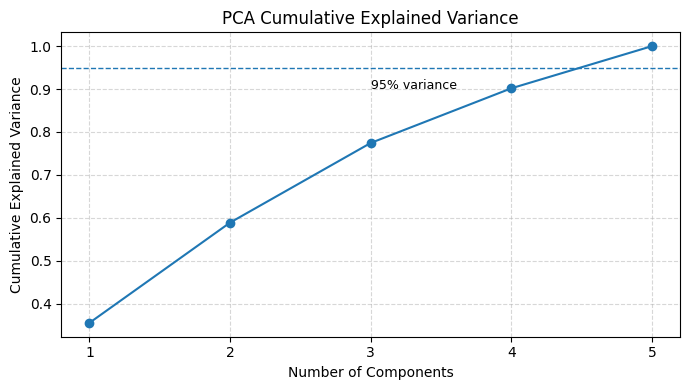

In [4]:
pca_full = PCA()
pca_full.fit(X)
explained_variance = pca_full.explained_variance_ratio_

print("Explained variance ratio:", explained_variance)
print("Total variance retained:", np.sum(explained_variance))
print("Variance kept by first 3 PCs:", round(explained_variance[:3].sum(), 3))
plot_cumulative_variance(explained_variance, show_target=0.95)


- The first component explains ~37% of the total variance.
- The first three components together explain ~78.2% of the variance.
- Around 4 to 5 components are needed to reach 95% variance.

In [5]:
pca = PCA(n_components=3, random_state=SEED)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=["PCA_1", "PCA_2", "PCA_3"])
df_pca["DEATH_EVENT"] = y.values

joblib.dump(df_pca, "../outputs/dim_red/df_pca.pkl")
plot_3d(X_pca, y, algorithm="PCA", target_name=TARGET_COL)

## t-SNE
---

In [6]:
tsne = TSNE(n_components=3, perplexity=50, random_state=SEED)
X_tsne = tsne.fit_transform(X)

df_tsne = pd.DataFrame(X_tsne, columns=["tSNE_1", "tSNE_2", "tSNE_3"])
df_tsne[TARGET_COL] = y.values

joblib.dump(df_tsne, os.path.join(OUTPUT_DIR, 'df_tsne.pkl'))
plot_3d(X_tsne, y, algorithm="t-SNE", target_name=TARGET_COL)

## UMAP

In [7]:
umap = u.UMAP(n_components=3, n_neighbors=30, min_dist=0.0)
X_umap = umap.fit_transform(X)

df_umap = pd.DataFrame(X_umap, columns=["UMAP_1", "UMAP_2", "UMAP_3"])
df_umap[TARGET_COL] = y.values

joblib.dump(df_umap, os.path.join(OUTPUT_DIR, 'df_umap.pkl'))
plot_3d(X_umap, y, algorithm="UMAP", target_name=TARGET_COL)

## Hybrid Mix (PCA1 + t-SNE1 + UMAP1)
---

In [8]:
X_combined = pd.DataFrame({
    "PCA_1": X_pca[:, 0],
    "tSNE_1": X_tsne[:, 0],
    "UMAP_1": X_umap[:, 0],
})

df_mix = pd.concat(
    [pd.DataFrame(X_combined, columns=X_combined.columns),
     pd.Series(y, name=TARGET_COL)],
    axis=1
)

joblib.dump(df_mix, os.path.join(OUTPUT_DIR, 'df_mix.pkl'))
plot_3d(X_combined, y, algorithm="Mix for the 1st component", target_name=TARGET_COL)

## Conclusions

In [11]:
rows = [
    eval_embedding("PCA",  X_pca,  y, X_ref=X),
    eval_embedding("t-SNE", X_tsne, y, X_ref=X),
    eval_embedding("UMAP",  X_umap, y, X_ref=X),
    eval_embedding("Mix",   X_combined.values, y, X_ref=X),
]
df = pd.DataFrame(rows)
auc_col = next(c for c in df.columns if c.startswith("CV ROC-AUC"))
df_sorted = df.sort_values(auc_col, ascending=False).reset_index(drop=True)
df_sorted

,Embedding,Classifier,CV ROC-AUC,Trustworthiness@10
0,PCA,LogisticRegression,0.895708,0.939213
1,Mix,LogisticRegression,0.863401,0.884237
2,UMAP,LogisticRegression,0.855124,0.965828
3,t-SNE,LogisticRegression,0.845792,0.983552


- PCA: _e.g., first PC ≈32%; first 3 PCs ≈72%; 4–5 PCs to reach 95%._
- t‑SNE: _note visible class separation (or overlap); best `perplexity`._
- UMAP: _note visible separation; best `n_neighbors` / `min_dist`._
- Hybrid: _whether combining first axes adds separability._

### Next steps
**Clustering on the best embedding**
  - Running k-means and DBSCAN.
  - Evaluation with internal indices: Silhouette, Calinski–Harabasz, Davies–Bouldin.
  - Visualizing cluster overlays on the 3D plots and export figures.